# CatBoost Multiclass Model

This notebook trains a CatBoost model to predict flight delay classes using temporal, route, airport and weather features

In [2]:
import pandas as pd
import numpy as np
import pyarrow
import holidays


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from catboost import CatBoostClassifier

# Load Dataset

In [3]:
data = pd.read_parquet(
    "/Users/Cliscia-Aula/Downloads/flights_with_weather.parquet"
)

data.shape

(2967376, 31)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2967376 entries, 0 to 2967375
Data columns (total 31 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   airline_icao                     str           
 1   origin_icao                      str           
 2   destination_icao                 str           
 3   dep_scheduled                    datetime64[us]
 4   dep_actual                       str           
 5   arr_scheduled                    datetime64[us]
 6   arr_actual                       str           
 7   origin_type                      str           
 8   origin_lat                       float64       
 9   origin_lon                       float64       
 10  origin_elevation_ft              float64       
 11  origin_region                    str           
 12  destination_type                 str           
 13  destination_lat                  float64       
 14  destination_lon                  float64     

In [5]:
data.head()

,airline_icao,origin_icao,destination_icao,dep_scheduled,dep_actual,arr_scheduled,arr_actual,origin_type,origin_lat,origin_lon,...,origin_wx_cloudcover,origin_wx_weathercode,origin_wx_surface_pressure,destination_wx_temperature_2m,destination_wx_precipitation,destination_wx_windspeed_10m,destination_wx_windgusts_10m,destination_wx_cloudcover,destination_wx_weathercode,destination_wx_surface_pressure
0,TAM,SBRJ,SBGR,2022-01-06 14:20:00,2022-01-06 14:31:00,2022-01-06 15:25:00,2022-01-06 15:29:00,large_airport,-22.910397,-43.16282,...,92.0,3.0,1005.459106,22.600000,5.4,17.873556,34.560001,98.0,63.0,926.656494
1,TAM,SBRJ,SBGR,2022-01-07 14:20:00,2022-01-07 14:47:00,2022-01-07 15:25:00,2022-01-07 15:42:00,large_airport,-22.910397,-43.16282,...,100.0,53.0,1009.652283,21.400000,1.5,20.617662,39.599998,100.0,61.0,929.092102
2,TAM,SBRJ,SBGR,2022-01-08 14:20:00,2022-01-08 14:12:00,2022-01-08 15:25:00,2022-01-08 15:12:00,large_airport,-22.910397,-43.16282,...,100.0,53.0,1011.151184,20.000000,0.2,22.907431,44.279999,100.0,51.0,929.817139
3,TAM,SBRJ,SBGR,2022-01-09 14:20:00,2022-01-09 14:16:00,2022-01-09 15:25:00,2022-01-09 15:15:00,large_airport,-22.910397,-43.16282,...,100.0,51.0,1013.350769,20.100000,0.1,21.382906,38.519997,100.0,51.0,930.394958
4,TAM,SBRJ,SBGR,2022-01-11 14:20:00,2022-01-11 14:20:00,2022-01-11 15:25:00,2022-01-11 15:15:00,large_airport,-22.910397,-43.16282,...,100.0,3.0,1008.753906,25.200001,0.0,4.349896,16.199999,100.0,3.0,927.982117


# Create Target

In [6]:
# Convert datetime columns
data["arr_scheduled"] = pd.to_datetime(data["arr_scheduled"])
data["arr_actual"] = pd.to_datetime(data["arr_actual"])

# Arrival delay in minutes
data["arr_delay_min"] = (
    data["arr_actual"] - data["arr_scheduled"]
).dt.total_seconds() / 60

In [7]:
def create_target(delay):
    if delay <= 0:
        return 0
    elif delay <= 60:
        return 1
    else:
        return 2


data["target"] = data["arr_delay_min"].apply(create_target)

In [8]:
data["target"].value_counts()

target
0    1845141
1    1037039
2      85196
Name: count, dtype: int64

# Feature Engineering

In [9]:
# Convert scheduled departure to datetime
data["dep_scheduled"] = pd.to_datetime(data["dep_scheduled"])

# Basic temporal features
data["dep_hour"] = data["dep_scheduled"].dt.hour
data["dep_minute"] = data["dep_scheduled"].dt.minute
data["dep_day_of_week"] = data["dep_scheduled"].dt.dayofweek
data["dep_month"] = data["dep_scheduled"].dt.month
data["dep_day_of_year"] = data["dep_scheduled"].dt.dayofyear

# Weekend flag
data["dep_is_weekend"] = data["dep_day_of_week"].isin([5, 6]).astype(int)

In [10]:
# Cyclical encoding
data["dep_hour_sin"] = np.sin(2 * np.pi * data["dep_hour"] / 24)
data["dep_hour_cos"] = np.cos(2 * np.pi * data["dep_hour"] / 24)

data["dep_dow_sin"] = np.sin(2 * np.pi * data["dep_day_of_week"] / 7)
data["dep_dow_cos"] = np.cos(2 * np.pi * data["dep_day_of_week"] / 7)

data["dep_month_sin"] = np.sin(2 * np.pi * data["dep_month"] / 12)
data["dep_month_cos"] = np.cos(2 * np.pi * data["dep_month"] / 12)

In [11]:
# Time block
def get_time_block(hour):
    if 0 <= hour <= 5:
        return "early_morning"
    elif 6 <= hour <= 11:
        return "morning"
    elif 12 <= hour <= 17:
        return "afternoon"
    else:
        return "night"


data["dep_time_block"] = data["dep_hour"].apply(get_time_block)

# Peak hour flag
data["dep_is_peak_hour"] = data["dep_hour"].between(7, 20).astype(int)

## Holiday Feature

In [12]:

br_holidays = holidays.Brazil()

data["dep_date"] = data["dep_scheduled"].dt.date

data["dep_is_holiday"] = (
    data["dep_date"]
    .isin(br_holidays)
    .astype(int)
)

In [13]:
data[["dep_scheduled", "dep_date", "dep_is_holiday"]].head()

,dep_scheduled,dep_date,dep_is_holiday
0,2022-01-06 14:20:00,2022-01-06,0
1,2022-01-07 14:20:00,2022-01-07,0
2,2022-01-08 14:20:00,2022-01-08,0
3,2022-01-09 14:20:00,2022-01-09,0
4,2022-01-11 14:20:00,2022-01-11,0


## Route Features

In [14]:
# Route identifier
data["route"] = (
    data["origin_icao"] + "_" + data["destination_icao"]
)

# Region pair
data["region_pair"] = (
    data["origin_region"] + "_" + data["destination_region"]
)

# Same region flag
data["same_region"] = (
    data["origin_region"] == data["destination_region"]
).astype(int)

# Elevation difference
data["elevation_diff_ft"] = (
    data["destination_elevation_ft"] - data["origin_elevation_ft"]
)

In [15]:
data[
    [
        "origin_icao",
        "destination_icao",
        "route",
        "origin_region",
        "destination_region",
        "region_pair",
        "same_region",
        "elevation_diff_ft"
    ]
].head()

,origin_icao,destination_icao,route,origin_region,destination_region,region_pair,same_region,elevation_diff_ft
0,SBRJ,SBGR,SBRJ_SBGR,BR-RJ,BR-SP,BR-RJ_BR-SP,0,2450.0
1,SBRJ,SBGR,SBRJ_SBGR,BR-RJ,BR-SP,BR-RJ_BR-SP,0,2450.0
2,SBRJ,SBGR,SBRJ_SBGR,BR-RJ,BR-SP,BR-RJ_BR-SP,0,2450.0
3,SBRJ,SBGR,SBRJ_SBGR,BR-RJ,BR-SP,BR-RJ_BR-SP,0,2450.0
4,SBRJ,SBGR,SBRJ_SBGR,BR-RJ,BR-SP,BR-RJ_BR-SP,0,2450.0


## Distance Features

In [17]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [18]:
data["distance_km"] = haversine(
    data["origin_lat"],
    data["origin_lon"],
    data["destination_lat"],
    data["destination_lon"]
)

In [20]:
data[
    [
        "origin_icao",
        "destination_icao",
        "distance_km"
    ]
].head()

,origin_icao,destination_icao,distance_km
0,SBRJ,SBGR,342.989852
1,SBRJ,SBGR,342.989852
2,SBRJ,SBGR,342.989852
3,SBRJ,SBGR,342.989852
4,SBRJ,SBGR,342.989852


## Flight Range

Classify flights based on their distance

In [21]:
def classify_flight_range(distance):
    if distance < 500:
        return "short"
    elif distance <= 1500:
        return "medium"
    else:
        return "long"


data["flight_range"] = data["distance_km"].apply(classify_flight_range)

In [22]:
data[
    [
        "origin_icao",
        "destination_icao",
        "distance_km",
        "flight_range"
    ]
].head()

,origin_icao,destination_icao,distance_km,flight_range
0,SBRJ,SBGR,342.989852,short
1,SBRJ,SBGR,342.989852,short
2,SBRJ,SBGR,342.989852,short
3,SBRJ,SBGR,342.989852,short
4,SBRJ,SBGR,342.989852,short


## Airport Size Features

In [23]:
airport_size_map = {
    "small_airport": 1,
    "medium_airport": 2,
    "large_airport": 3
}

data["origin_airport_size"] = (
    data["origin_type"]
    .map(airport_size_map)
    .fillna(2)
)

data["destination_airport_size"] = (
    data["destination_type"]
    .map(airport_size_map)
    .fillna(2)
)

In [24]:
data["both_large_airports"] = (
    (data["origin_airport_size"] == 3)
    &
    (data["destination_airport_size"] == 3)
).astype(int)

In [25]:
trunk_routes = [
    "SBRJ_SBGR",
    "SBGR_SBRJ",
    "SBSP_SBRJ",
    "SBRJ_SBSP",
    "SBGR_SBSV",
    "SBSV_SBGR",
    "SBGR_SBRF",
    "SBRF_SBGR"
]

data["is_trunk_route"] = (
    data["route"]
    .isin(trunk_routes)
    .astype(int)
)

In [26]:
data[
    [
        "route",
        "origin_airport_size",
        "destination_airport_size",
        "both_large_airports",
        "is_trunk_route"
    ]
].head()

,route,origin_airport_size,destination_airport_size,both_large_airports,is_trunk_route
0,SBRJ_SBGR,3.0,3.0,1,1
1,SBRJ_SBGR,3.0,3.0,1,1
2,SBRJ_SBGR,3.0,3.0,1,1
3,SBRJ_SBGR,3.0,3.0,1,1
4,SBRJ_SBGR,3.0,3.0,1,1


## Weather Features

In [27]:
def classify_weather(code):

    if code == 0:
        return "clear"

    elif code in [1, 2, 3]:
        return "cloudy"

    elif code in [45, 48]:
        return "fog"

    elif code in [51, 53, 55, 56, 57, 61, 63, 65]:
        return "rain"

    elif code in [71, 73, 75, 77]:
        return "snow"

    elif code in [80, 81, 82]:
        return "showers"

    elif code in [95, 96, 99]:
        return "storm"

    else:
        return "other"

In [29]:
data["origin_wx_condition"] = (
    data["origin_wx_weathercode"]
    .apply(classify_weather)
)

data["destination_wx_condition"] = (
    data["destination_wx_weathercode"]
    .apply(classify_weather)
)

In [30]:
data["origin_wx_is_fog"] = (
    data["origin_wx_weathercode"]
    .isin([45, 48])
    .astype(int)
)

data["origin_wx_is_rain"] = (
    data["origin_wx_weathercode"]
    .isin([51, 53, 55, 56, 57, 61, 63, 65, 80, 81, 82])
    .astype(int)
)

data["origin_wx_is_storm"] = (
    data["origin_wx_weathercode"]
    .isin([95, 96, 99])
    .astype(int)
)

In [31]:
data["destination_wx_is_fog"] = (
    data["destination_wx_weathercode"]
    .isin([45, 48])
    .astype(int)
)

data["destination_wx_is_rain"] = (
    data["destination_wx_weathercode"]
    .isin([51, 53, 55, 56, 57, 61, 63, 65, 80, 81, 82])
    .astype(int)
)

data["destination_wx_is_storm"] = (
    data["destination_wx_weathercode"]
    .isin([95, 96, 99])
    .astype(int)
)

In [32]:
data[
[
    "origin_wx_weathercode",
    "origin_wx_condition",
    "origin_wx_is_fog",
    "origin_wx_is_rain",
    "origin_wx_is_storm",
    "destination_wx_weathercode",
    "destination_wx_condition",
    "destination_wx_is_fog",
    "destination_wx_is_rain",
    "destination_wx_is_storm"
]
].head()

,origin_wx_weathercode,origin_wx_condition,origin_wx_is_fog,origin_wx_is_rain,origin_wx_is_storm,destination_wx_weathercode,destination_wx_condition,destination_wx_is_fog,destination_wx_is_rain,destination_wx_is_storm
0,3.0,cloudy,0,0,0,63.0,rain,0,1,0
1,53.0,rain,0,1,0,61.0,rain,0,1,0
2,53.0,rain,0,1,0,51.0,rain,0,1,0
3,51.0,rain,0,1,0,51.0,rain,0,1,0
4,3.0,cloudy,0,0,0,3.0,cloudy,0,0,0


## Experimental Weather Features

Create additional weather features based on differences and severe weather indicators.

In [33]:
# Weather differences between origin and destination
data["temp_diff"] = (
    data["origin_wx_temperature_2m"] - data["destination_wx_temperature_2m"]
)

data["wind_diff"] = (
    data["origin_wx_windspeed_10m"] - data["destination_wx_windspeed_10m"]
)

data["gust_diff"] = (
    data["origin_wx_windgusts_10m"] - data["destination_wx_windgusts_10m"]
)

data["pressure_diff"] = (
    data["origin_wx_surface_pressure"] - data["destination_wx_surface_pressure"]
)

data["cloud_diff"] = (
    data["origin_wx_cloudcover"] - data["destination_wx_cloudcover"]
)

In [34]:
# Severe weather indicators
data["heavy_rain_origin"] = (
    data["origin_wx_precipitation"] > 5
).astype(int)

data["heavy_rain_destination"] = (
    data["destination_wx_precipitation"] > 5
).astype(int)

data["strong_wind_origin"] = (
    data["origin_wx_windspeed_10m"] > 30
).astype(int)

data["strong_wind_destination"] = (
    data["destination_wx_windspeed_10m"] > 30
).astype(int)

data["strong_gust_origin"] = (
    data["origin_wx_windgusts_10m"] > 50
).astype(int)

data["strong_gust_destination"] = (
    data["destination_wx_windgusts_10m"] > 50
).astype(int)

In [35]:
# Combined bad weather indicators
data["bad_weather_origin"] = (
    (data["heavy_rain_origin"] == 1)
    | (data["strong_wind_origin"] == 1)
    | (data["strong_gust_origin"] == 1)
    | (data["origin_wx_is_fog"] == 1)
    | (data["origin_wx_is_storm"] == 1)
).astype(int)

data["bad_weather_destination"] = (
    (data["heavy_rain_destination"] == 1)
    | (data["strong_wind_destination"] == 1)
    | (data["strong_gust_destination"] == 1)
    | (data["destination_wx_is_fog"] == 1)
    | (data["destination_wx_is_storm"] == 1)
).astype(int)

In [36]:
data[
    [
        "temp_diff",
        "wind_diff",
        "gust_diff",
        "pressure_diff",
        "cloud_diff",
        "heavy_rain_origin",
        "heavy_rain_destination",
        "strong_wind_origin",
        "strong_wind_destination",
        "bad_weather_origin",
        "bad_weather_destination"
    ]
].head()

,temp_diff,wind_diff,gust_diff,pressure_diff,cloud_diff,heavy_rain_origin,heavy_rain_destination,strong_wind_origin,strong_wind_destination,bad_weather_origin,bad_weather_destination
0,6.481499,-7.133724,-6.840002,78.802612,-6.0,0,1,0,0,0,1
1,3.131500,0.256128,10.080002,80.560181,0.0,0,0,0,0,0,0
2,3.881498,-9.011244,-9.719997,81.334045,0.0,0,0,0,0,0,0
3,4.181499,-17.556053,-23.759998,82.955811,0.0,0,0,0,0,0,0
4,0.431498,6.833304,10.080002,80.771790,0.0,0,0,0,0,0,0


In [42]:
# Bad weather simultaneously at origin and destination airports
data["both_bad_weather"] = (
    (data["bad_weather_origin"] == 1)
    & (data["bad_weather_destination"] == 1)
).astype(int)

# Bad weather at least at one airport
data["any_bad_weather"] = (
    (data["bad_weather_origin"] == 1)
    | (data["bad_weather_destination"] == 1)
).astype(int)

In [38]:
data[
    [
        "bad_weather_origin",
        "bad_weather_destination",
        "both_bad_weather",
        "any_bad_weather"
    ]
].head()

,bad_weather_origin,bad_weather_destination,both_bad_weather,any_bad_weather
0,0,1,0,1
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0


In [43]:
# Weather severity score at origin airport
data["origin_weather_score"] = (
    data["origin_wx_is_fog"]
    + data["origin_wx_is_rain"]
    + data["origin_wx_is_storm"]
    + data["heavy_rain_origin"]
    + data["strong_wind_origin"]
)

In [44]:
# Weather severity score at destination airport
data["destination_weather_score"] = (
    data["destination_wx_is_fog"]
    + data["destination_wx_is_rain"]
    + data["destination_wx_is_storm"]
    + data["heavy_rain_destination"]
    + data["strong_wind_destination"]
)

In [41]:
data[
    [
        "origin_weather_score",
        "destination_weather_score"
    ]
].head()

,origin_weather_score,destination_weather_score
0,0,2
1,1,1
2,1,1
3,1,1
4,0,0


# Historical Delay Features

Features created to capture delay propagation effects and historical delay patterns across routes, airlines and airports.

These variables are designed to represent how previous delays may influence future flights, a phenomenon commonly known as delay propagation.

In [49]:
# Sort flights chronologically
data = data.sort_values("dep_scheduled")

In [50]:
# Delay of previous flight on the same route
data["previous_route_delay"] = (
    data.groupby("route")["arr_delay_min"]
    .shift(1)
)

In [51]:
# Rolling average delay of the last 3 flights on the same route
data["rolling_mean_last_3_route"] = (
    data.groupby("route")["arr_delay_min"]
    .transform(lambda x: x.shift(1).rolling(3).mean())
)

In [52]:
# Rolling average delay of the last 5 flights on the same route
data["rolling_mean_last_5_route"] = (
    data.groupby("route")["arr_delay_min"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

In [53]:
# Number of consecutive delayed flights on the same route
data["previous_route_was_delayed"] = (
    (data.groupby("route")["arr_delay_min"]
     .shift(1) >= 15)
).astype(int)

# Feature Dictionary

## Features Temporais

Colunas derivadas da data e horário previstos de partida.

| Coluna | Tipo | Descrição |
|---------|------|------------|
| `dep_hour` | int | Hora prevista da partida (0-23) |
| `dep_day_of_week` | int | Dia da semana da partida (0=segunda, 6=domingo) |
| `dep_month` | int | Mês da partida |
| `dep_hour_sin` | float | Representação cíclica da hora usando seno |
| `dep_hour_cos` | float | Representação cíclica da hora usando cosseno |
| `dep_dow_sin` | float | Representação cíclica do dia da semana usando seno |
| `dep_dow_cos` | float | Representação cíclica do dia da semana usando cosseno |
| `dep_month_sin` | float | Representação cíclica do mês usando seno |
| `dep_month_cos` | float | Representação cíclica do mês usando cosseno |
| `dep_time_block` | str | Faixa do dia (`early_morning`, `morning`, `afternoon`, `night`) |
| `dep_is_peak_hour` | int (0/1) | Indica se o voo ocorre em horário de pico (7h às 20h) |

## Features de Rota e Região

Colunas derivadas da origem, destino e características geográficas da rota.

| Coluna | Tipo | Descrição |
|---------|------|------------|
| `route` | str | Combinação entre aeroporto de origem e destino |
| `origin_region` | str | Região do aeroporto de origem |
| `destination_region` | str | Região do aeroporto de destino |
| `region_pair` | str | Combinação das regiões de origem e destino |
| `same_region` | int (0/1) | Indica se origem e destino pertencem à mesma região |
| `elevation_diff_ft` | float | Diferença de altitude entre os aeroportos em pés |
| `distance_km` | float | Distância aproximada entre os aeroportos em quilômetros |

## Features dos Aeroportos

Colunas relacionadas ao porte dos aeroportos e à importância da rota.

| Coluna | Tipo | Descrição |
|---------|------|------------|
| `origin_airport_size` | int | Porte do aeroporto de origem |
| `destination_airport_size` | int | Porte do aeroporto de destino |
| `both_large_airports` | int (0/1) | Indica se ambos os aeroportos são classificados como grandes |
| `is_trunk_route` | int (0/1) | Indica se a rota é uma rota principal de alta movimentação |

## Features de Distância

Colunas relacionadas à distância e às diferenças geográficas entre origem e destino.

| Coluna | Tipo | Descrição |
|---------|------|------------|
| `distance_km` | float | Distância aproximada entre os aeroportos em quilômetros |
| `elevation_diff_ft` | float | Diferença de altitude entre os aeroportos em pés |

##  Features dos Aeroportos

Colunas relacionadas ao porte dos aeroportos e à importância da rota.

| Coluna | Tipo | Descrição |
|---------|------|------------|
| `origin_airport_size` | int | Porte do aeroporto de origem |
| `destination_airport_size` | int | Porte do aeroporto de destino |
| `both_large_airports` | int (0/1) | Indica se ambos os aeroportos são classificados como grandes |
| `is_trunk_route` | int (0/1) | Indica se a rota é uma rota principal de alta movimentação |

##  Features Meteorológicas

Colunas derivadas das condições climáticas observadas nos aeroportos de origem e destino.

| Coluna | Tipo | Descrição |
|---------|------|------------|
| `origin_wx_temperature_2m` | float | Temperatura do ar na origem (°C) |
| `origin_wx_precipitation` | float | Precipitação na origem (mm) |
| `origin_wx_windspeed_10m` | float | Velocidade do vento na origem (km/h) |
| `origin_wx_windgusts_10m` | float | Rajadas de vento na origem (km/h) |
| `origin_wx_cloudcover` | float | Cobertura de nuvens na origem (%) |
| `origin_wx_weathercode` | int | Código da condição meteorológica na origem |
| `origin_wx_surface_pressure` | float | Pressão atmosférica na origem (hPa) |
| `destination_wx_temperature_2m` | float | Temperatura do ar no destino (°C) |
| `destination_wx_precipitation` | float | Precipitação no destino (mm) |
| `destination_wx_windspeed_10m` | float | Velocidade do vento no destino (km/h) |
| `destination_wx_windgusts_10m` | float | Rajadas de vento no destino (km/h) |
| `destination_wx_cloudcover` | float | Cobertura de nuvens no destino (%) |
| `destination_wx_weathercode` | int | Código da condição meteorológica no destino |
| `destination_wx_surface_pressure` | float | Pressão atmosférica no destino (hPa) |

## Experimental Weather Features

Colunas criadas para capturar diferenças e severidade climática entre origem e destino.

| Coluna | Tipo | Descrição |
|---------|------|------------|
| `temp_diff` | float | Diferença de temperatura entre origem e destino |
| `wind_diff` | float | Diferença da velocidade do vento entre origem e destino |
| `ust_diff` | float | Diferença das rajadas de vento entre origem e destino |
| `pressure_diff` | float | Diferença da pressão atmosférica entre origem e destino |
| `cloud_diff` | float | Diferença da cobertura de nuvens entre origem e destino |
| `heavy_rain_origin` | int (0/1) | Chuva forte na origem |
| `heavy_rain_destination` | int (0/1) | Chuva forte no destino |
| `strong_wind_origin` | int (0/1) | Vento forte na origem |
| `trong_wind_destination` | int (0/1) | Vento forte no destino |
| `bad_weather_origin` | int (0/1) | Clima severo na origem |
| `bad_weather_destination` | int (0/1) | Clima severo no destino |
| `both_bad_weather` | int (0/1) | Clima severo simultaneamente na origem e no destino |
| `any_bad_weather` | int (0/1) | Clima severo em pelo menos um dos aeroportos |
| `origin_weather_score` | int | Pontuação de severidade climática da origem |
| `destination_weather_score` | int | Pontuação de severidade climática do destino |

## Historical Delay Features

Columns created to capture delay propagation effects and historical delay patterns across routes.

These variables aim to represent how delays from previous flights may affect subsequent flights, a phenomenon commonly observed in airline operations and known as delay propagation.

| Coluna | Tipo | Descrição |
|----------|------|------------|
| `previous_route_delay` | float | Arrival delay (in minutes) of the previous flight on the same route |
| `rolling_mean_last_3_route` | float | Average arrival delay of the last 3 flights on the same route |
| `rolling_mean_last_5_route` | float | Average arrival delay of the last 5 flights on the same route |
| `previous_route_was_delayed` | int (0/1) | Indicates whether the previous flight on the same route was delayed by at least 15 minutes |

In [57]:
X.columns.tolist()

['airline_icao',
 'origin_icao',
 'destination_icao',
 'dep_scheduled',
 'dep_actual',
 'arr_scheduled',
 'arr_actual',
 'origin_type',
 'origin_lat',
 'origin_lon',
 'origin_elevation_ft',
 'origin_region',
 'destination_type',
 'destination_lat',
 'destination_lon',
 'destination_elevation_ft',
 'destination_region',
 'origin_wx_temperature_2m',
 'origin_wx_precipitation',
 'origin_wx_windspeed_10m',
 'origin_wx_windgusts_10m',
 'origin_wx_cloudcover',
 'origin_wx_weathercode',
 'origin_wx_surface_pressure',
 'destination_wx_temperature_2m',
 'destination_wx_precipitation',
 'destination_wx_windspeed_10m',
 'destination_wx_windgusts_10m',
 'destination_wx_cloudcover',
 'destination_wx_weathercode',
 'destination_wx_surface_pressure',
 'dep_hour',
 'dep_minute',
 'dep_day_of_week',
 'dep_month',
 'dep_day_of_year',
 'dep_is_weekend',
 'dep_hour_sin',
 'dep_hour_cos',
 'dep_dow_sin',
 'dep_dow_cos',
 'dep_month_sin',
 'dep_month_cos',
 'dep_time_block',
 'dep_is_peak_hour',
 'dep_date'

In [58]:
X = data.drop(
    columns=[
        "target",
        "arr_delay_min",
        "dep_actual",
        "arr_actual",
        "dep_scheduled",
        "arr_scheduled",
        "dep_date"
    ]
)

y = data["target"]

In [59]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [60]:
# Categorical features
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(categorical_features)

['airline_icao', 'origin_icao', 'destination_icao', 'origin_type', 'origin_region', 'destination_type', 'destination_region', 'dep_time_block', 'route', 'region_pair', 'flight_range', 'origin_wx_condition', 'destination_wx_condition']


/var/folders/q9/nq_67mg97h1c04k7r8451qbc0000gq/T/ipykernel_2178/2289382561.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


# CatBoost Model Training

In [62]:
# CatBoost model
model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    random_seed=42,
    verbose=100
)

# Train model
model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

0:	learn: 0.6060101	total: 4.83s	remaining: 40m 10s
100:	learn: 0.6248858	total: 8m 48s	remaining: 34m 49s
200:	learn: 0.6294081	total: 18m 6s	remaining: 26m 56s
300:	learn: 0.6331674	total: 27m 10s	remaining: 17m 57s
400:	learn: 0.6353269	total: 36m 43s	remaining: 9m 4s
499:	learn: 0.6372899	total: 46m 26s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='TotalF1', iterations=500, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=100)

In [64]:
# Predictions
y_pred = model.predict(X_test)

# Flatten predictions
y_pred = y_pred.ravel()

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.88      0.78    369029
           1       0.59      0.35      0.44    207408
           2       0.63      0.02      0.04     17039

    accuracy                           0.67    593476
   macro avg       0.64      0.42      0.42    593476
weighted avg       0.66      0.67      0.64    593476



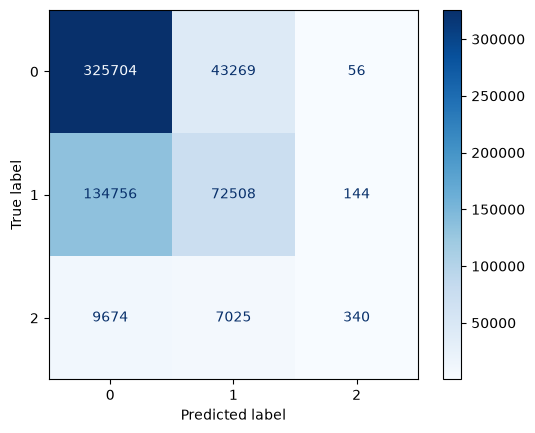

In [65]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.show()

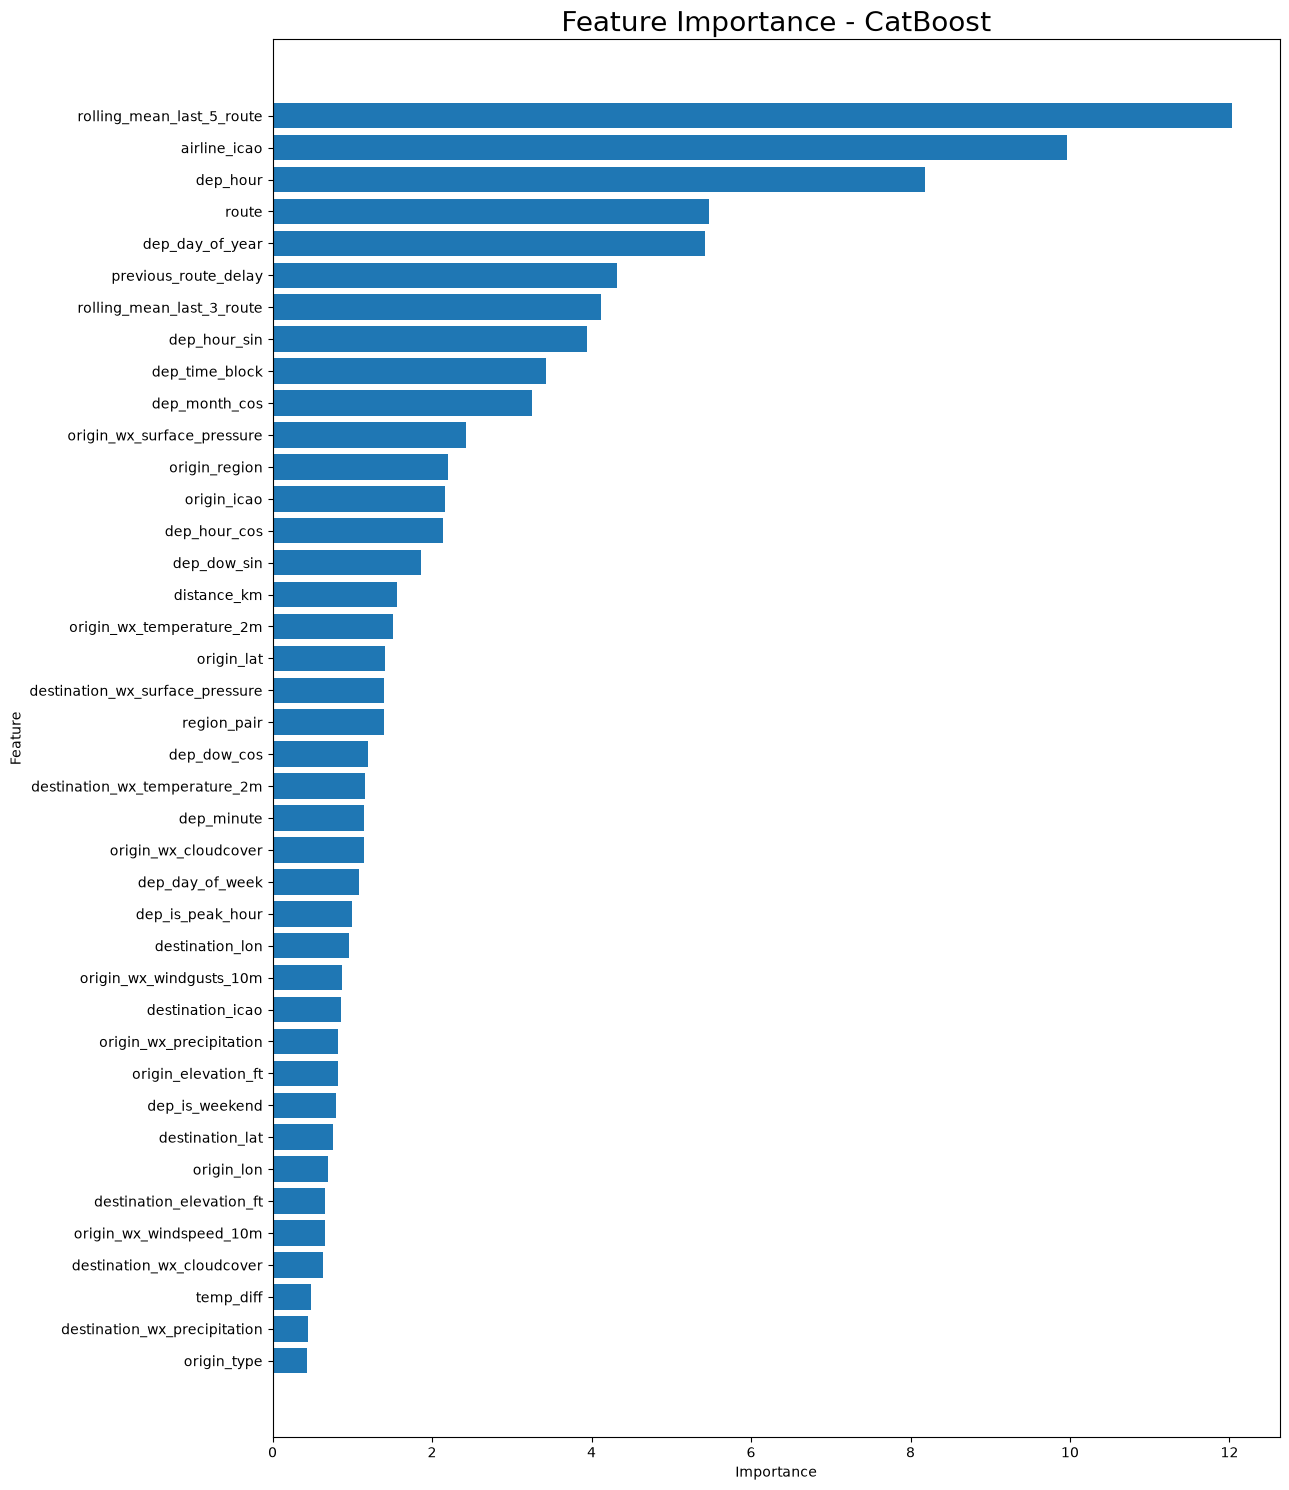

In [86]:
# 40 most important features
top_features = importance_df.head(40).sort_values("importance")

plt.figure(figsize=(13, 15))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Feature Importance - CatBoost", fontsize=20)
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [67]:
data["target"].value_counts().sort_index()

target
0    1845141
1    1037039
2      85196
Name: count, dtype: int64

In [68]:
data["target"].value_counts(normalize=True).sort_index()

target
0    0.621809
1    0.349480
2    0.028711
Name: proportion, dtype: float64

# CatBoost with Balanced Class Weights

Second experiment using automatic class balancing to improve performance on minority classes

In [69]:
# CatBoost model with balanced weights
model_balanced = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=100
)

# Train model
model_balanced.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

0:	learn: 0.4588881	total: 5.92s	remaining: 49m 15s
100:	learn: 0.4972635	total: 9m 10s	remaining: 36m 14s
200:	learn: 0.5055045	total: 18m 26s	remaining: 27m 25s
300:	learn: 0.5114151	total: 28m 32s	remaining: 18m 52s
400:	learn: 0.5159133	total: 38m	remaining: 9m 22s
499:	learn: 0.5193343	total: 47m 48s	remaining: 0us


CatBoostClassifier(auto_class_weights='Balanced', depth=6, eval_metric='TotalF1', iterations=500, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=100)

In [70]:
y_pred_balanced = model_balanced.predict(X_test)
y_pred_balanced = y_pred_balanced.ravel()

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.76      0.61      0.67    369029
           1       0.48      0.45      0.46    207408
           2       0.08      0.48      0.14     17039

    accuracy                           0.55    593476
   macro avg       0.44      0.51      0.42    593476
weighted avg       0.64      0.55      0.59    593476



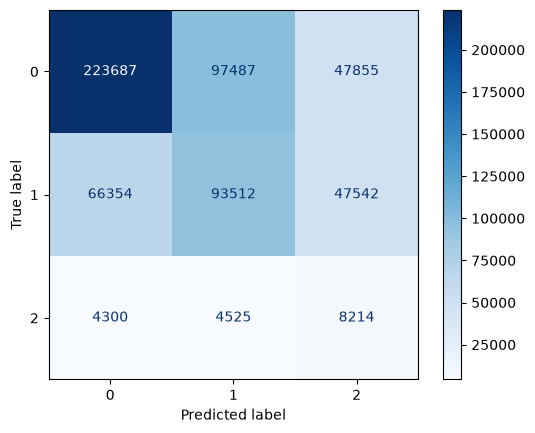

In [71]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_balanced,
    cmap="Blues"
)

plt.show()

In [72]:
y_proba_balanced = model_balanced.predict_proba(X_test)

roc_auc_balanced = roc_auc_score(
    y_test,
    y_proba_balanced,
    multi_class="ovr",
    average="weighted"
)

print(f"ROC-AUC: {roc_auc_balanced:.4f}")

ROC-AUC: 0.6853


# Conclusion

Two CatBoost multiclass models were evaluated:

- A baseline CatBoost model.
- A CatBoost model with automatic class balancing.

The baseline model achieved higher overall accuracy but struggled to identify severe delays (class 2), resulting in very low recall for this minority class.

Introducing balanced class weights substantially improved the recall of class 2, showing that the model became more sensitive to severe delays. However, this improvement came at the expense of overall accuracy and precision, leading to a higher number of false positives.

Feature importance analysis revealed that historical delay features, such as:

- `rolling_mean_last_5_route`
- `previous_route_delay`
- `rolling_mean_last_3_route`

were among the most influential variables. This finding provides evidence of delay propagation effects, where previous delays can influence subsequent flights on the same route.

Meteorological variables also contributed to the model, although their impact was generally lower than operational and historical features.

Despite these improvements, multiclass prediction remains challenging due to the strong class imbalance and the absence of operational variables that are not available in the dataset.

Future work may include:

- Hyperparameter tuning.
- Testing LightGBM.
- Exploring binary classification approaches.
